# Car Color Classifier ResNet

## Imports

In [1]:
import os
import shutil
import zipfile
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, optimizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from PIL import Image
from google.colab import drive

## Parameters

In [2]:
ZIP_PATH = "/content/drive/MyDrive/Confirmed_fronts.zip"
PATH = '/content/confirmed_fronts'
NEW_PATH = '/content/confirmed_fronts_new'
IMAGE_SIZE = (180, 180)
IMAGE_SHAPE = (180, 180, 3)
BATCH_SIZE = 32

## Dataset

### Load from Drive

In [3]:
drive.mount('/content/drive')

if not os.path.isdir(PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(".")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Restructuring

As is car images were grouped by manufacturer and production year. We want to group images by color, which is in the name of each image.

In [4]:
def restructure(root_dir, new_dir):
    for subdir, _, files in os.walk(root_dir):
        for f in files:
            try:
                color = f.split('$$')[3].strip().lower()

                target_dir = os.path.join(new_dir, color)
                os.makedirs(target_dir, exist_ok=True)

                copy_from = os.path.join(subdir, f)
                copy_to = os.path.join(target_dir, f)
                shutil.copy(copy_from, copy_to)

            except Exception as e:
                print(f"Error with {f}: {str(e)}")
                continue


restructure(PATH, NEW_PATH)

### Cleanup

In [5]:
def process_classes(root_dir, min_elements):
    class_counts = {}

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)

        if os.path.isdir(class_path):
            file_count = len(os.listdir(class_path))
            print(f"Class: {class_name}, Elements: {file_count}")

            if file_count >= min_elements:
                class_counts[class_name] = file_count
            else:
                print(f"  Removing class '{class_name}' (elements < {min_elements})")
                shutil.rmtree(class_path)

    return class_counts


classes = process_classes(NEW_PATH, 2000)

Class: brown, Elements: 911
  Removing class 'brown' (elements < 2000)
Class: bronze, Elements: 329
  Removing class 'bronze' (elements < 2000)
Class: indigo, Elements: 1
  Removing class 'indigo' (elements < 2000)
Class: white, Elements: 9395
Class: pink, Elements: 87
  Removing class 'pink' (elements < 2000)
Class: silver, Elements: 7770
Class: magenta, Elements: 9
  Removing class 'magenta' (elements < 2000)
Class: beige, Elements: 600
  Removing class 'beige' (elements < 2000)
Class: yellow, Elements: 667
  Removing class 'yellow' (elements < 2000)
Class: multicolour, Elements: 196
  Removing class 'multicolour' (elements < 2000)
Class: gold, Elements: 217
  Removing class 'gold' (elements < 2000)
Class: turquoise, Elements: 26
  Removing class 'turquoise' (elements < 2000)
Class: green, Elements: 777
  Removing class 'green' (elements < 2000)
Class: purple, Elements: 362
  Removing class 'purple' (elements < 2000)
Class: blue, Elements: 8483
Class: navy, Elements: 1
  Removing cla

### Class distribution

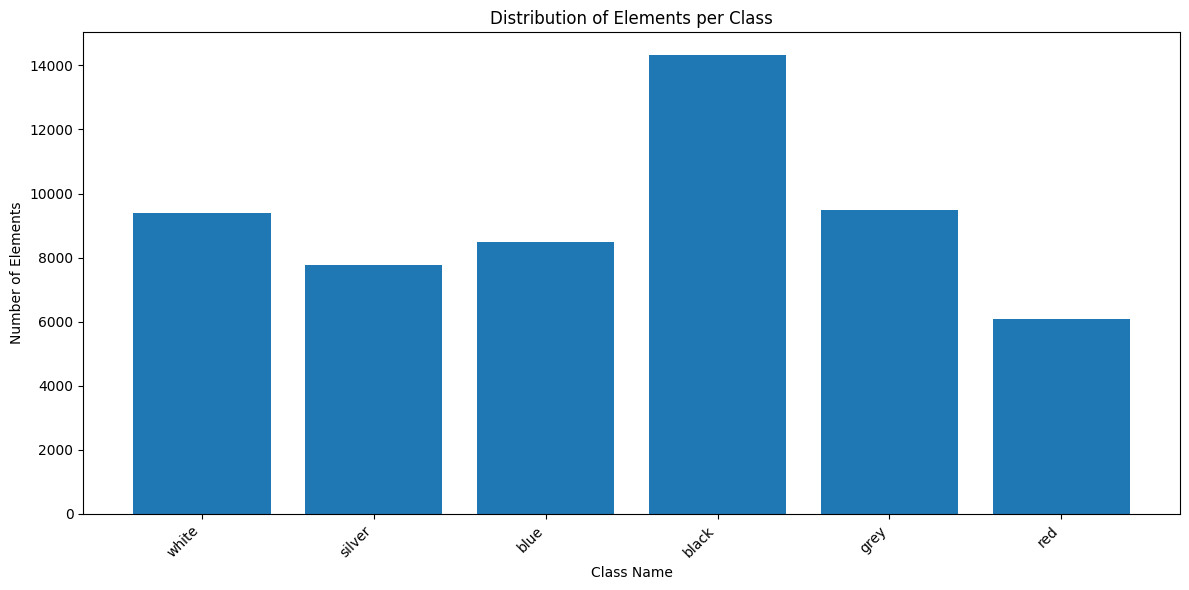

In [6]:
names = list(classes.keys())
values = list(classes.values())

plt.figure(figsize=(12, 6))
plt.bar(names, values)
plt.xlabel("Class Name")
plt.ylabel("Number of Elements")
plt.title("Distribution of Elements per Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Train/val, resize, reshape

In [7]:
x_train, x_val = tf.keras.utils.image_dataset_from_directory(
    NEW_PATH,
    validation_split=0.2,
    subset="both",
    seed=42,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE
)

Found 55534 files belonging to 6 classes.
Using 44428 files for training.
Using 11106 files for validation.


## The Net

In [8]:
def residual_block(x, filters, strides=1):
    shortcut = x
    x = layers.Conv2D(filters, 3, strides=strides, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    if strides != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=strides, padding="same")(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

def build_resnet(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(64, 7, strides=2, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D(3, strides=2, padding="same")(x)
    x = residual_block(x, 64)
    x = residual_block(x, 64)
    x = residual_block(x, 128, strides=2)
    x = residual_block(x, 128)
    x = residual_block(x, 256, strides=2)
    x = residual_block(x, 256)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inputs, outputs)

model = build_resnet(IMAGE_SHAPE, len(classes.keys()))

model.compile(optimizer=optimizers.Adam(), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(x_train, epochs=10)

Epoch 1/10
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 90s 57ms/step - accuracy: 0.4919 - loss: 7.4873
Epoch 2/10
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 130s 53ms/step - accuracy: 0.7265 - loss: 0.7210
Epoch 3/10
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 81s 53ms/step - accuracy: 0.7922 - loss: 0.5717
Epoch 4/10
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.8196 - loss: 0.5052
Epoch 5/10
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.8336 - loss: 0.4633
Epoch 6/10
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.8491 - loss: 0.4216
Epoch 7/10
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.8631 - loss: 0.3868
Epoch 8/10
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.8700 - loss: 0.3706
Epoch 9/10
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.8874 - loss: 0.3228
Epoch 10/10
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.8920 - loss: 0.3015


In [9]:
val_predictions = model.predict(x_val)
val_predicted_labels = np.argmax(val_predictions, axis=1)

348/348 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step


## Validation

### F1 macro

In [10]:
labels = x_val.class_names
true_val_labels = []
for _, label in x_val:
    true_val_labels.extend(label.numpy())

true_val_labels = np.array(true_val_labels)
f1_macro = f1_score(true_val_labels, val_predicted_labels, average="macro")
print(f"F1 Macro Score: {f1_macro}")

F1 Macro Score: 0.837042911831306


### Confusion Matrix

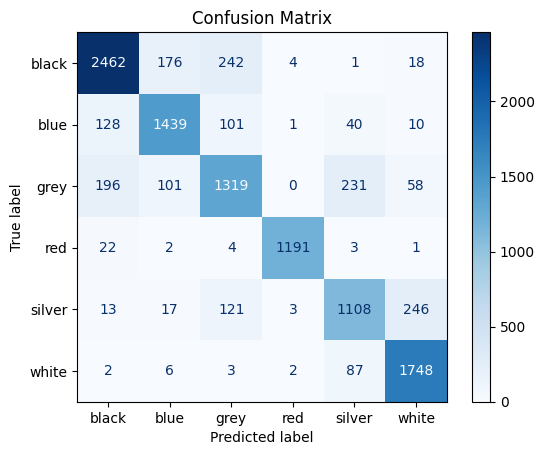

In [11]:
cm = confusion_matrix(true_val_labels, val_predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()